In [29]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [13]:
insurance_data = pd.read_csv("insurance.csv")


X=insurance_data.drop(columns=["charges"])
y= insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first = True, dtype = int)


X["sex"]= X["sex"].map({"female":1,"male":0})
X["smoker"]= X["smoker"].map({"yes":1,"no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"]  = X["bmi"] * X["smoker"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for alphas0.001= 20922599.871035963
MSE for alphas0.1= 20921803.698431373
MSE for alphas1= 20914832.635089137
MSE for alphas2= 20908106.779954523
MSE for alphas3= 20901927.931570224
MSE for alphas5= 20890881.000633497
MSE for alphas10= 20872844.794796683
MSE for alphas20= 20877828.53237883
MSE for alphas30= 20937537.133939773
MSE for alphas40= 21046489.29389078
MSE for alphas50= 21196929.86960891
MSE for alphas100= 22423172.68602325


<Axes: >

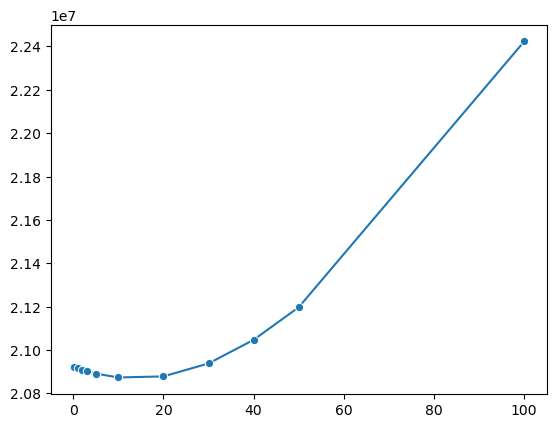

In [21]:
alphas = [0.001,0.1, 1,2,3,5,10,20,30,40,50,100]
mses= []

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for alphas{a}=",mse)
    mses.append(mse)

sns.lineplot(x= alphas,y= mses,marker ="o")

In [30]:
from sklearn.linear_model import LassoCV
a = [0.001,0.1, 1,2,3,5,10,20,30,40,50]
lasso_cv_model = LassoCV(
    alphas= a,
    cv=5,
    max_iter= 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train, y_train)
print("best alpha value: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse= mean_squared_error(y_test, y_pred)
r2 =r2_score(y_test,y_pred)
print("mse = ", mse)
print("r2 =", r2)

best alpha value:  0.001
mse =  20922599.871035963
r2 = 0.8652317499151699
